# Person A — Notebook 3 FAST (GPT-2-XL): KL-Stabilized Reconsolidation
**CS 590NN | Amogh | Apr 19 — FAST GPT-2-XL arm**

Fast version of NB3 v2 on GPT-2-XL. Same KL-stabilized edit, reduced scope.

**Speed config:**
- **N_SAMPLES = 20** (was 50)
- **STEP_COUNTS = [5, 20]** (was [1, 5, 10, 20])
- **End-of-loop KL measurement only** — removes the per-step measurement
  overhead that doubled forward passes in v2 polish. KL_final still accurate,
  but no kl_history/p_new_history trajectories.
- Everything else identical to NB3 v2 on Qwen.

**Output:** `week5_harness_output_kl_gpt2xl.json`

**Runtime:** ~35-45 min on H100 (was ~2.5-3.5 hr).


### 3.0 Install

In [ ]:
import subprocess, sys, os
def pip(args): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + args)
pip(["numpy==1.26.4"])
pip(["transformer-lens", "transformers", "datasets", "accelerate", "einops", "jaxtyping", "matplotlib"])
print("Done. Restarting runtime...")
os.kill(os.getpid(), 9)


### 3.1 Imports

In [1]:
import torch, json, re, requests, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformer_lens import HookedTransformer
import matplotlib.pyplot as plt
import numpy as np

# Fail fast if GPU is missing — avoids wasting 1 min downloading 6 GB to CPU
assert torch.cuda.is_available(), (
    "CUDA not available. Go to Runtime → Change runtime type → Hardware accelerator → "
    "GPU (H100 if possible). Then Disconnect → Reconnect and re-run."
)

DEVICE = "cuda"
print(f"GPU: {torch.cuda.get_device_name(0)}")
free, total = torch.cuda.mem_get_info()
print(f"Mem: {free/1e9:.1f}/{total/1e9:.1f} GB")

torch.manual_seed(42); random.seed(42)
RESULTS_DIR = Path("results"); FIGS_DIR = Path("figures")
RESULTS_DIR.mkdir(exist_ok=True); FIGS_DIR.mkdir(exist_ok=True)


GPU: NVIDIA A100-SXM4-80GB
Mem: 84.6/85.1 GB


### 3.2 Load GPT-2-XL

In [2]:
MODEL_NAME = "gpt2-xl"
model = HookedTransformer.from_pretrained(
    MODEL_NAME, center_unembed=True, center_writing_weights=False,
    fold_ln=True, refactor_factored_attn_matrices=False, device=DEVICE,
)
model.set_use_attn_result(True)
model.eval()
model.tokenizer.pad_token = model.tokenizer.eos_token
print(f"Loaded: {MODEL_NAME} | {model.cfg.n_layers} layers")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-xl into HookedTransformer
Loaded: gpt2-xl | 48 layers


### 3.3 Upload Circuit Log

In [3]:
from google.colab import files
print("Upload week2_circuit_log_gpt2xl.json from Notebook 1 FAST...")
uploaded = files.upload()
with open(next(iter(uploaded.keys()))) as f:
    circuit_log = json.load(f)
print(f"Loaded {len(circuit_log)} circuits. Avg n_mlp={sum(e['n_mlp'] for e in circuit_log)/len(circuit_log):.2f}")


Upload week2_circuit_log_gpt2xl.json from Notebook 1 FAST...


Saving week2_circuit_log_gpt2xl.json to week2_circuit_log_gpt2xl.json
Loaded 20 circuits. Avg n_mlp=3.30


### 3.4 Load CounterFact (20 samples)

In [4]:
@dataclass
class EditSample:
    prompt: str; target_new: str; target_true: str
    related_prompts: List[str] = field(default_factory=list)

raw_data = requests.get("https://rome.baulab.info/data/dsets/counterfact.json", timeout=60).json()
N_SAMPLES = 20

def parse_counterfact(raw):
    return EditSample(
        prompt=raw["requested_rewrite"]["prompt"].format(raw["requested_rewrite"]["subject"]),
        target_new=" " + raw["requested_rewrite"]["target_new"]["str"],
        target_true=" " + raw["requested_rewrite"]["target_true"]["str"],
        related_prompts=[p for p in raw.get("neighborhood_prompts", [])[:3] if isinstance(p, str)],
    )

cf_samples = [parse_counterfact(raw_data[i]) for i in range(N_SAMPLES)]
assert len(cf_samples) == len(circuit_log), f"sample/circuit count mismatch: {len(cf_samples)} vs {len(circuit_log)}"
print(f"Loaded {N_SAMPLES} samples.")


Loaded 20 samples.


### 3.5 Neutral Anchor Set (32 prompts)

In [5]:
NEUTRAL_PROMPTS = [
    "The sum of two and three is", "Twelve divided by four equals",
    "The square root of nine is", "Ten times ten equals",
    "The capital of Japan is", "The largest ocean on Earth is the",
    "Mount Everest is located in the", "The Amazon River flows through",
    "Water boils at one hundred degrees", "The chemical symbol for gold is",
    "Plants produce oxygen through a process called", "The Earth orbits the",
    "A week contains seven", "The primary colors are red, blue, and",
    "Humans have two lungs and one", "A triangle has three",
    "The opposite of hot is", "A baby cat is called a",
    "The past tense of run is", "A group of fish is called a",
    "The Industrial Revolution began in the eighteenth",
    "The Renaissance was a period of cultural",
    "World War Two ended in the year", "The Wright Brothers invented the",
    "A computer's main processor is the", "The world wide web was invented by",
    "An algorithm is a sequence of", "The unit of electrical resistance is the",
    "Roses are typically red while violets are",
    "The sky appears blue because of light",
    "A year contains twelve", "The freezing point of water is zero degrees",
]
assert len(NEUTRAL_PROMPTS) == 32


### 3.6 Edit Functions (FAST — end-of-loop KL measurement only)

In [6]:
def restore_weights(model, state):
    with torch.no_grad():
        for name, param in model.named_parameters():
            param.copy_(state[name])
    torch.cuda.empty_cache()

def cache_reference_logits(model, prompts):
    cache = []
    model.eval()
    with torch.no_grad():
        for p in prompts:
            tokens = model.to_tokens(p)
            logits = model(tokens)
            ref_lp = torch.log_softmax(logits[0, -1, :], dim=-1).detach().clone()
            cache.append((tokens, ref_lp))
    return cache

def get_circuit_params(model, circuit_attn, circuit_mlp):
    params = []
    for (layer, head) in circuit_attn:
        try: params.append(model.blocks[layer].attn.W_O)
        except Exception: pass
    for layer in circuit_mlp:
        try:
            params.append(model.blocks[layer].mlp.W_in)
            params.append(model.blocks[layer].mlp.W_out)
        except Exception: pass
    return params

def contrastive_loss(model, sample):
    tokens  = model.to_tokens(sample.prompt)
    new_id  = model.to_tokens(sample.target_new,  prepend_bos=False)[0, 0]
    true_id = model.to_tokens(sample.target_true, prepend_bos=False)[0, 0]
    logits  = model(tokens)
    lp = torch.nn.functional.log_softmax(logits[0, -1, :], dim=-1)
    loss = -lp[new_id] + lp[true_id]
    return loss, lp[new_id].exp().item(), lp[true_id].exp().item()

def kl_loss_neutral(model, ref_cache):
    total = 0.0
    for tokens, ref_lp in ref_cache:
        logits = model(tokens)
        edit_lp = torch.log_softmax(logits[0, -1, :], dim=-1)
        total = total + (ref_lp.exp() * (ref_lp - edit_lp)).sum()
    return total / len(ref_cache)

def kl_loss_neutral_eval(model, ref_cache):
    total = 0.0
    model.eval()
    with torch.no_grad():
        for tokens, ref_lp in ref_cache:
            logits = model(tokens)
            edit_lp = torch.log_softmax(logits[0, -1, :], dim=-1)
            total += (ref_lp.exp() * (ref_lp - edit_lp)).sum().item()
    return total / len(ref_cache)


def run_edit_fast(model, sample, circuit_attn, circuit_mlp, n_steps,
                  lr=5e-3, beta_kl=0.1, grad_clip=1.0, ref_cache=None):
    """FAST version: no per-step kl_history; just kl_initial and kl_final."""
    params = get_circuit_params(model, circuit_attn, circuit_mlp)
    if not params:
        params = [p for layer in model.blocks for p in [layer.mlp.W_in, layer.mlp.W_out]]

    for p in model.parameters(): p.requires_grad_(False)
    for p in params: p.requires_grad_(True)
    optimizer = torch.optim.Adam(params, lr=lr)

    model.eval()
    with torch.no_grad():
        _, baseline, _ = contrastive_loss(model, sample)
    kl_initial = kl_loss_neutral_eval(model, ref_cache) if ref_cache is not None else 0.0

    for _ in range(n_steps):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        loss, _, _ = contrastive_loss(model, sample)
        if ref_cache is not None and beta_kl > 0:
            kl = kl_loss_neutral(model, ref_cache)
            loss = loss + beta_kl * kl
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=grad_clip)
        optimizer.step()
        del loss

    torch.cuda.empty_cache()
    model.eval()
    with torch.no_grad():
        _, final_p_new, final_p_true = contrastive_loss(model, sample)
    # Measure KL ONCE at end (not per-step — this is the speed win)
    kl_final = kl_loss_neutral_eval(model, ref_cache) if ref_cache is not None else 0.0
    for p in model.parameters(): p.requires_grad_(True)

    return {
        "edit_success":  final_p_new,
        "baseline_prob": baseline,
        "final_p_true":  final_p_true,
        "kl_initial":    kl_initial,
        "kl_final":      kl_final,
        "delta_kl":      kl_final - kl_initial,
        "status":        "ok",
    }


print("Snapshotting GPT-2-XL weights to CPU (~6 GB)...")
original_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
torch.cuda.empty_cache()
free, _ = torch.cuda.mem_get_info()
print(f"GPU free: {free/1e9:.1f} GB")


Snapshotting GPT-2-XL weights to CPU (~6 GB)...
GPU free: 77.9 GB


### 3.7 Ablation (STEP_COUNTS = [5, 20])

In [7]:
STEP_COUNTS = [5, 20]
LR = 5e-3; BETA_KL = 0.1; GRAD_CLIP = 1.0
ablation_results = {s: [] for s in STEP_COUNTS}

for n_steps in STEP_COUNTS:
    print(f"\n=== {n_steps}-step ablation ===")
    n_failed = 0
    for i in range(N_SAMPLES):
        try:
            restore_weights(model, original_state)
            ref_cache = cache_reference_logits(model, NEUTRAL_PROMPTS) if BETA_KL > 0 else None
            res = run_edit_fast(
                model, cf_samples[i],
                circuit_log[i]["attn_heads"],
                circuit_log[i]["mlp_layers"],
                n_steps=n_steps, lr=LR, beta_kl=BETA_KL,
                grad_clip=GRAD_CLIP, ref_cache=ref_cache,
            )
            res["idx"] = i; res["n_steps"] = n_steps
            ablation_results[n_steps].append(res)
            del ref_cache
            torch.cuda.empty_cache()
            if i % 5 == 0:
                free = torch.cuda.mem_get_info()[0] / 1e9
                print(f"  [{i+1:>2}/{N_SAMPLES}]  edit={res['edit_success']:.4f}  kl={res['kl_final']:.3f}  gpu_free={free:.1f}GB")
        except Exception as e:
            n_failed += 1
            print(f"  [{i+1:>2}/{N_SAMPLES}]  FAILED: {type(e).__name__}: {str(e)[:80]}")
            ablation_results[n_steps].append({
                "idx": i, "n_steps": n_steps, "status": "failed",
                "error": f"{type(e).__name__}: {str(e)[:200]}",
                "edit_success": 0.0, "baseline_prob": 0.0, "final_p_true": 0.0,
                "kl_initial": 0.0, "kl_final": 0.0, "delta_kl": 0.0,
            })
            torch.cuda.empty_cache()

    ok = [r for r in ablation_results[n_steps] if r.get("status") == "ok"]
    if ok:
        avg_e = sum(r["edit_success"] for r in ok) / len(ok)
        avg_k = sum(r["kl_final"] for r in ok) / len(ok)
        flipped = sum(1 for r in ok if r["edit_success"] > 0.5)
        print(f"  SUMMARY  edit={avg_e:.4f}  kl={avg_k:.3f}  flip={flipped}/{len(ok)}  failed={n_failed}")

restore_weights(model, original_state)
with open(RESULTS_DIR / "week5_ablation_kl_gpt2xl.json", "w") as f:
    json.dump({str(k): v for k, v in ablation_results.items()}, f, indent=2)



=== 5-step ablation ===
  [ 1/20]  edit=1.0000  kl=28.921  gpu_free=77.3GB


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


  [ 6/20]  edit=0.9999  kl=35.953  gpu_free=74.0GB
  [11/20]  edit=1.0000  kl=27.177  gpu_free=73.1GB
  [16/20]  edit=1.0000  kl=30.463  gpu_free=73.1GB
  SUMMARY  edit=0.9934  kl=20.834  flip=20/20  failed=0

=== 20-step ablation ===
  [ 1/20]  edit=0.9991  kl=2.670  gpu_free=73.0GB
  [ 6/20]  edit=0.9999  kl=38.301  gpu_free=73.7GB
  [11/20]  edit=1.0000  kl=3.103  gpu_free=73.0GB
  [16/20]  edit=1.0000  kl=2.526  gpu_free=73.0GB
  SUMMARY  edit=0.9899  kl=4.003  flip=20/20  failed=0


### 3.8 Figures + Output

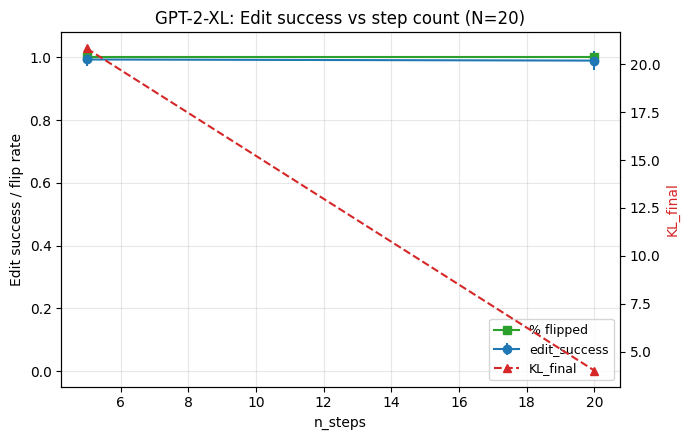

  NB3 FAST (GPT-2-XL) — 20260419_062037
  OurMethod_5step_gpt2xl            edit=0.9934  kl=20.834  flip%=100.0
  OurMethod_20step_gpt2xl           edit=0.9899  kl=4.003  flip%=100.0

  Download: /content/PersonA_Notebook3_gpt2xl_FAST_20260419_062037.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# Edit success + KL bar chart (no trajectory figure since we don't have per-step)
steps = sorted(ablation_results.keys())
edit_mu, edit_sd, flip_rate, kl_mu = [], [], [], []
for s in steps:
    ok = [r for r in ablation_results[s] if r.get("status") == "ok"]
    es = np.array([r["edit_success"] for r in ok])
    kl = np.array([r["kl_final"] for r in ok])
    edit_mu.append(es.mean()); edit_sd.append(es.std())
    flip_rate.append(sum(1 for r in ok if r["edit_success"] > 0.5) / len(ok))
    kl_mu.append(kl.mean())

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.errorbar(steps, edit_mu, yerr=edit_sd, marker="o", color="C0", label="edit_success")
ax1.plot(steps, flip_rate, marker="s", color="C2", label="% flipped")
ax1.set_xlabel("n_steps"); ax1.set_ylabel("Edit success / flip rate")
ax1.set_ylim(-0.05, 1.08); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(steps, kl_mu, marker="^", color="C3", linestyle="--", label="KL_final")
ax2.set_ylabel("KL_final", color="C3")
l1, _ = ax1.get_legend_handles_labels(); l2, _ = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, [h.get_label() for h in l1 + l2], loc="lower right", fontsize=9)
ax1.set_title(f"GPT-2-XL: Edit success vs step count (N={N_SAMPLES})")
fig.tight_layout(); fig.savefig(FIGS_DIR / "fig_edit_vs_steps_gpt2xl.png", dpi=160); plt.show()


rows, summary = [], {}
for n_steps, results in ablation_results.items():
    key = f"OurMethod_{n_steps}step_gpt2xl"
    for r in results:
        rows.append({
            "method": key, "model": MODEL_NAME, "idx": r["idx"], "n_steps": n_steps,
            "edit_success": round(r["edit_success"], 4),
            "baseline_prob": round(r["baseline_prob"], 4),
            "over_extinction": None,
            "kl_initial": round(r["kl_initial"], 4),
            "kl_final":   round(r["kl_final"],   4),
            "delta_kl":   round(r["delta_kl"],   4),
            "kl_active": BETA_KL > 0, "beta_kl": BETA_KL, "grad_clip": GRAD_CLIP,
            "status": r.get("status", "ok"), "error": r.get("error", None),
        })
    ok = [r for r in results if r.get("status") == "ok"]
    if ok:
        summary[key] = {
            "avg_edit_success": round(sum(r["edit_success"] for r in ok) / len(ok), 4),
            "avg_kl_final":     round(sum(r["kl_final"] for r in ok) / len(ok), 4),
            "pct_flipped":      round(sum(1 for r in ok if r["edit_success"] > 0.5) / len(ok), 4),
            "n_ok": len(ok), "n_failed": len(results) - len(ok),
        }

with open(RESULTS_DIR / "week5_harness_output_kl_gpt2xl.json", "w") as f:
    json.dump({
        "model": MODEL_NAME, "kl_active": True, "beta_kl": BETA_KL, "grad_clip": GRAD_CLIP,
        "neutral_set_size": len(NEUTRAL_PROMPTS),
        "notebook_version": "fast_gpt2xl",
        "rows": rows, "summary": summary,
    }, f, indent=2)


import shutil
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

with open(RESULTS_DIR / f"summary_nb3_gpt2xl_FAST_{timestamp}.json", "w") as f:
    json.dump({
        "author": "Amogh",
        "notebook": "Notebook 3 FAST (GPT-2-XL) — KL-Stabilized Reconsolidation",
        "model": MODEL_NAME, "timestamp": timestamp,
        "n_samples": N_SAMPLES, "step_counts": STEP_COUNTS,
        "fast_version": True,
        "beta_kl": BETA_KL, "grad_clip": GRAD_CLIP,
        "summary": summary,
    }, f, indent=2)

all_dir = Path("zip_contents")
all_dir.mkdir(exist_ok=True)
for p in RESULTS_DIR.glob("*"): shutil.copy2(p, all_dir / p.name)
for p in FIGS_DIR.glob("*"):    shutil.copy2(p, all_dir / p.name)
zip_path = f"/content/PersonA_Notebook3_gpt2xl_FAST_{timestamp}"
shutil.make_archive(zip_path, "zip", all_dir)

print("=" * 66)
print(f"  NB3 FAST (GPT-2-XL) — {timestamp}")
print("=" * 66)
for m, s in summary.items():
    print(f"  {m:<32}  edit={s['avg_edit_success']:.4f}  kl={s['avg_kl_final']:.3f}  flip%={100*s['pct_flipped']:>5.1f}")
print(f"\n  Download: {zip_path}.zip")

from google.colab import files
files.download(f"{zip_path}.zip")
